In [1]:
!pip install -U transformers
!pip install -q huggingface_hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 144.3 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.55.2
    Uninstalling transformers-4.55.2:
      Successfully uninstalled transformers-4.55.2


In [2]:
# Cell 1: Git LFS installation and repository cloning
# Install git-lfs
!sudo apt-get update
!sudo apt-get install -y git-lfs
!git lfs install

# Clone the Geneformer repository
!git clone https://huggingface.co/ctheodoris/Geneformer

# Cell 2: Install the Geneformer Python package
!cd Geneformer && pip install .

# Optional: Verify installation by importing
import os
import sys
# Add the cloned repo's directory to sys.path if 'pip install .' doesn't make it available immediately
# (Sometimes Colab needs a restart, but this can help)
if '/content/Geneformer' not in sys.path:
    sys.path.insert(0, '/content/Geneformer')

from geneformer import Classifier, EmbExtractor
print("Geneformer imported successfully!")

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [346 B]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,937 kB]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:12 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Get:13 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 P

/content/Geneformer/geneformer/evaluation_utils.py:194: SyntaxWarning: invalid escape sequence '\p'
  label = f"{model_name} (AUC {roc_auc:0.2f} $\pm$ {roc_auc_sd:0.2f})"


In [3]:
!ls /content/Geneformer

build		   geneformer.egg-info		MANIFEST.in
config.json	   Geneformer-V1-10M		model.safetensors
docs		   Geneformer-V2-104M		README.md
examples	   Geneformer-V2-104M_CLcancer	requirements.txt
fine_tuned_models  Geneformer-V2-316M		setup.py
geneformer	   generation_config.json	training_args.bin


In [4]:
from geneformer import EmbExtractor

In [5]:
# Create the directory
# !mkdir -p /content/Genecorpus-30M

# Clone with sparse checkout for only example_input_files
# !git clone --filter=blob:none --sparse https://huggingface.co/datasets/ctheodoris/Genecorpus-30M /content/Genecorpus-30M

# Configure sparse checkout to only include example_input_files
# !cd /content/Genecorpus-30M && git sparse-checkout set example_input_files

# Check what was downloaded
# !ls -la /content/Genecorpus-30M/
# !find /content/Genecorpus-30M -type f -name "*.dataset"

In [6]:
# Clone only the `example_input_files` folder
!git clone --filter=blob:none --no-checkout https://huggingface.co/datasets/ctheodoris/Genecorpus-30M
%cd Genecorpus-30M
!git sparse-checkout init --cone
!git sparse-checkout set example_input_files
!git checkout main

Cloning into 'Genecorpus-30M'...
remote: Enumerating objects: 140, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 140 (delta 40), reused 0 (delta 0), pack-reused 74 (from 1)
Receiving objects: 100% (140/140), 23.24 KiB | 23.24 MiB/s, done.
Resolving deltas: 100% (68/68), done.
/content/Genecorpus-30M
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 33 (delta 2), reused 0 (delta 0), pack-reused 15 (from 1)
Receiving objects: 100% (33/33), 992.18 KiB | 19.84 MiB/s, done.
Resolving deltas: 100% (2/2), done.
Filtering content: 100% (20/20), 2.32 GiB | 51.97 MiB/s, done.
Already on 'main'
Your branch is up to date with 'origin/main'.
Encountered 1 file(s) that may not have been copied correctly on Windows:
	example_input_files/cell_classification/disease_classification/human_dcm_hcm_nf.dataset/dataset.arrow

See: `git lfs help

In [7]:
!cd /content/
!pwd

from huggingface_hub import snapshot_download
import os

# Create directory
os.makedirs("/content/datasets", exist_ok=True)

# Download only the disease_classification directory
dataset_path = snapshot_download(
    repo_id="ctheodoris/Genecorpus-30M",
    repo_type="dataset",
    local_dir="/content/datasets",
    local_dir_use_symlinks=False,
    allow_patterns="example_input_files/cell_classification/disease_classification/*"
)

print(f"Downloaded to: {dataset_path}")
!ls -la /content/datasets/example_input_files/cell_classification/disease_classification/

/content/Genecorpus-30M


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:982: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

example_input_files/cell_classification/(…):   0%|          | 0.00/4.88G [00:00<?, ?B/s]

example_input_files/cell_classification/(…):   0%|          | 0.00/1.18k [00:00<?, ?B/s]

example_input_files/cell_classification/(…):   0%|          | 0.00/383 [00:00<?, ?B/s]

Downloaded to: /content/datasets
total 12
drwxr-xr-x 3 root root 4096 Aug 21 19:45 .
drwxr-xr-x 3 root root 4096 Aug 21 19:44 ..
drwxr-xr-x 2 root root 4096 Aug 21 19:45 human_dcm_hcm_nf.dataset


In [8]:
!pwd
!ls -la ./Geneformer/fine_tuned_models/

/content/Genecorpus-30M
ls: cannot access './Geneformer/fine_tuned_models/': No such file or directory


In [9]:
!pwd
!echo "-------"
%cd /content/
!pwd
!echo "-------"
!ls -1
!echo "-------"
!echo "Genecorpus-30M"
!ls -1 /content/Genecorpus-30M
!echo "-------"
!ls -1
!echo "-------"
!echo "Geneformer"
!ls -1 /content/Geneformer
!echo "-------"
!echo "datasets"
!ls -1 /content/datasets
!echo "-------"

/content/Genecorpus-30M
-------
/content
/content
-------
datasets
Genecorpus-30M
Geneformer
sample_data
-------
Genecorpus-30M
example_input_files
genecorpus_30M_2048_lengths.pkl
genecorpus_30M_2048_sorted_lengths.pkl
README.md
token_dictionary.pkl
-------
datasets
Genecorpus-30M
Geneformer
sample_data
-------
Geneformer
build
config.json
docs
examples
fine_tuned_models
geneformer
geneformer.egg-info
Geneformer-V1-10M
Geneformer-V2-104M
Geneformer-V2-104M_CLcancer
Geneformer-V2-316M
generation_config.json
MANIFEST.in
model.safetensors
README.md
requirements.txt
setup.py
training_args.bin
-------
datasets
example_input_files
-------


In [10]:
!echo "fined tune model"
!ls -la /content/Geneformer/fine_tuned_models/Geneformer-V1-10M_CellClassifier_cardiomyopathies_220224/
!echo "----------------------"
!echo "disease classification"
!ls -1 Genecorpus-30M/example_input_files/cell_classification/disease_classification
!ls -1 Genecorpus-30M/example_input_files/cell_classification/disease_classification/human_dcm_hcm_nf.dataset

fined tune model
total 112192
drwxr-xr-x 2 root root     4096 Aug 21 19:42 .
drwxr-xr-x 3 root root     4096 Aug 21 19:42 ..
-rw-r--r-- 1 root root      930 Aug 21 19:42 config.json
-rw-r--r-- 1 root root 73720721 Aug 21 19:42 optimizer.pt
-rw-r--r-- 1 root root 41115113 Aug 21 19:42 pytorch_model.bin
-rw-r--r-- 1 root root    14657 Aug 21 19:42 rng_state.pth
-rw-r--r-- 1 root root      623 Aug 21 19:42 scheduler.pt
-rw-r--r-- 1 root root     3726 Aug 21 19:42 trainer_state.json
-rw-r--r-- 1 root root     2607 Aug 21 19:42 training_args.bin
----------------------
disease classification
human_dcm_hcm_nf.dataset
dataset.arrow
dataset_info.json
state.json


In [11]:
!echo "gene dictionaries"
!ls -la /content/Geneformer/geneformer/gene_dictionaries_30m

import os

# Verify the file exists
token_path = "/content/Geneformer/geneformer/gene_dictionaries_30m/token_dictionary_gc30M.pkl"
print(f"Token dictionary exists: {os.path.exists(token_path)}")
print(f"Full path: {os.path.abspath(token_path)}")

# List all token files to see what's available
!ls -la /content/Geneformer/geneformer/*token*

gene dictionaries
total 3364
drwxr-xr-x 2 root root    4096 Aug 21 19:42 .
drwxr-xr-x 5 root root    4096 Aug 21 19:43 ..
-rw-r--r-- 1 root root  584125 Aug 21 19:42 ensembl_mapping_dict_gc30M.pkl
-rw-r--r-- 1 root root  940965 Aug 21 19:42 gene_median_dictionary_gc30M.pkl
-rw-r--r-- 1 root root 1117117 Aug 21 19:42 gene_name_id_dict_gc30M.pkl
-rw-r--r-- 1 root root  788424 Aug 21 19:42 token_dictionary_gc30M.pkl
Token dictionary exists: True
Full path: /content/Geneformer/geneformer/gene_dictionaries_30m/token_dictionary_gc30M.pkl
-rw-r--r-- 1 root root 425590 Aug 21 19:42 /content/Geneformer/geneformer/token_dictionary_gc104M.pkl
-rw-r--r-- 1 root root  34294 Aug 21 19:42 /content/Geneformer/geneformer/tokenizer.py


In [12]:
# What is <cls>?

# The <cls> token is prepended to the input sequence.
# It stands for "classification", and is meant to capture a summary representation of the entire input.
# After passing the sequence through the Transformer, the final hidden state corresponding to the <cls> token is typically used as the aggregate representation for classification tasks.

# GPT4 info : it might not be accurate !

# Geneformer V1 and V2 both utilize a special <cls> token in their transformer models — but with some differences in implementation and usage context.

# 🔹 Geneformer V1
# Based on BERT architecture, which uses the <cls> token at the start of the input.
# The <cls> token embedding is used for tasks like cell classification, gene embedding extraction, and regression.
# When extracting embeddings in cell classification mode, the output corresponding to <cls> (usually the first token) is used as the representation of the cell.

#🔹 Geneformer V2
# Also maintains a classification token, although implementation and tokenization may differ slightly.
# It uses an updated model structure and dictionary (shared_gene_dict.json) which includes the <cls> token.
# The V2 architecture is more modular, but still retains the <cls> token for tasks requiring whole-sequence representation.

In [13]:
import datetime
import os
from geneformer import EmbExtractor

In [14]:
!echo ""
!echo "model : Geneformer-V1-10M"
!ls -1 /content/Geneformer/Geneformer-V1-10M
!echo ""
!echo "model : Geneformer-V2-104M"
!ls -1 /content/Geneformer/Geneformer-V2-104M
!echo ""
!echo "fined tune model"
!ls -la /content/Geneformer/fine_tuned_models/Geneformer-V1-10M_CellClassifier_cardiomyopathies_220224/


model : Geneformer-V1-10M
config.json
model.safetensors
pytorch_model.bin
training_args.bin

model : Geneformer-V2-104M
config.json
generation_config.json
model.safetensors
training_args.bin

fined tune model
total 112192
drwxr-xr-x 2 root root     4096 Aug 21 19:42 .
drwxr-xr-x 3 root root     4096 Aug 21 19:42 ..
-rw-r--r-- 1 root root      930 Aug 21 19:42 config.json
-rw-r--r-- 1 root root 73720721 Aug 21 19:42 optimizer.pt
-rw-r--r-- 1 root root 41115113 Aug 21 19:42 pytorch_model.bin
-rw-r--r-- 1 root root    14657 Aug 21 19:42 rng_state.pth
-rw-r--r-- 1 root root      623 Aug 21 19:42 scheduler.pt
-rw-r--r-- 1 root root     3726 Aug 21 19:42 trainer_state.json
-rw-r--r-- 1 root root     2607 Aug 21 19:42 training_args.bin


In [15]:
# Use V1 Model with CLS token (if you need CLS embeddings)
# If you want to extract <cls> embeddings, switch to a V1 model and provide a token dictionary that includes <cls>.
# About V2 model (model_version="V2") : the input data might be tokenized using a V1 tokenizer, which prepends a <cls> token.
# V2 Geneformer does not use <cls> tokens. So when emb_mode="cls" is attempted, it crashes because the first token is not <cls>.

In [16]:
# Check for available token dictionaries
!find /content -name "*token_dictionary*" -type f
!find /content -name "*.pkl" -type f | grep -i token

/content/Geneformer/build/lib/geneformer/token_dictionary_gc104M.pkl
/content/Geneformer/build/lib/geneformer/gene_dictionaries_30m/token_dictionary_gc30M.pkl
/content/Geneformer/geneformer/token_dictionary_gc104M.pkl
/content/Geneformer/geneformer/gene_dictionaries_30m/token_dictionary_gc30M.pkl
/content/Genecorpus-30M/token_dictionary.pkl
/content/Geneformer/build/lib/geneformer/token_dictionary_gc104M.pkl
/content/Geneformer/build/lib/geneformer/gene_dictionaries_30m/token_dictionary_gc30M.pkl
/content/Geneformer/geneformer/token_dictionary_gc104M.pkl
/content/Geneformer/geneformer/gene_dictionaries_30m/token_dictionary_gc30M.pkl
/content/Genecorpus-30M/token_dictionary.pkl


In [17]:
!ls -1 /content/Geneformer/geneformer/gene_dictionaries_30m/

ensembl_mapping_dict_gc30M.pkl
gene_median_dictionary_gc30M.pkl
gene_name_id_dict_gc30M.pkl
token_dictionary_gc30M.pkl


In [18]:


# Model versions

model_version1="V1"
# model_version2="V2"

# Define paths

token_dictionary_file = "/content/Geneformer/geneformer/gene_dictionaries_30m/token_dictionary_gc30M.pkl"  # or your V1 or V2 token dict
token_dict_path = token_dictionary_file

model_directory = "/content/Geneformer/Geneformer-V1-10M"      # pretrained or fine-tuned model folder
# model_directory = "/content/Geneformer/Geneformer-V2-104M"   # pretrained or fine-tuned model folder
# model_directory = "/content/Geneformer/fine_tuned_models/Geneformer-V1-10M_CellClassifier_cardiomyopathies_220224/"

input_data_file = "/content/Genecorpus-30M/example_input_files/cell_classification/disease_classification/human_dcm_hcm_nf.dataset"

# Verify the paths

if os.path.exists(token_dictionary_file):
    print(f"✅ File exists: {token_dictionary_file}")
else:
    print(f"❌ File does NOT exist: {token_dictionary_file}")

if os.path.exists(model_directory):
    print(f"✅ File exists: {model_directory}")
else:
    print(f"❌ File does NOT exist: {model_directory}")


if os.path.exists(input_data_file):
    print(f"✅ File exists: {input_data_file}")
else:
    print(f"❌ File does NOT exist: {input_data_file}")

✅ File exists: /content/Geneformer/geneformer/gene_dictionaries_30m/token_dictionary_gc30M.pkl
✅ File exists: /content/Geneformer/Geneformer-V1-10M
✅ File exists: /content/Genecorpus-30M/example_input_files/cell_classification/disease_classification/human_dcm_hcm_nf.dataset


In [19]:
!ls -1 /content/Geneformer/geneformer/gene_dictionaries_30m/

ensembl_mapping_dict_gc30M.pkl
gene_median_dictionary_gc30M.pkl
gene_name_id_dict_gc30M.pkl
token_dictionary_gc30M.pkl


In [20]:
# For V1 models:

# They do use the <cls> token — it is automatically prepended to the input.
# You must ensure that emb_mode="cell" is used when extracting cell embeddings.
# In your case, you don’t need to set emb_mode manually if you are using the CellClassifier model with model_version="V1", because that is the default behavior.

# However:
# If you manually set emb_mode="cls" or use code intended for V2 (which may handle embedding modes differently), it can trigger an assertion or lead to unexpected behavior.

In [21]:
!echo "verify the input files and output directory"

verify the input files and output directory


In [22]:
# WARNING:geneformer.emb_extractor:model_version selected as V1 so changing emb_mode from 'cls' to 'cell' as V1 models do not have a <cls> token.

In [23]:
from geneformer import EmbExtractor

# input_data_file
input_data_file = "/content/Genecorpus-30M/example_input_files/cell_classification/disease_classification/human_dcm_hcm_nf.dataset"

token_dictionary_file = "/content/Geneformer/geneformer/gene_dictionaries_30m/token_dictionary_gc30M.pkl"  # or your V1 or V2 token dict
# token_dictionary_file = "/content/Geneformer/geneformer/gene_dictionaries_30m/shared_gene_dict.json"
token_dict_path = token_dictionary_file

# model choices :
# model_directory = "/content/Geneformer/Geneformer-V1-10M"      # pretrained or fine-tuned model folder
# model_directory = "/content/Geneformer/Geneformer-V2-104M"   # pretrained or fine-tuned model folder
model_directory = "/content/Geneformer/fine_tuned_models/Geneformer-V1-10M_CellClassifier_cardiomyopathies_220224/"

In [24]:
import os
import warnings
import numpy as np
from collections import Counter
from datasets import load_from_disk

# Load the dataset
print(f"\n�� Loading dataset...")
try:
    dataset = load_from_disk(input_data_file)
    print(f"✅ Dataset loaded successfully!")
except Exception as e:
    print(f"❌ Failed to load dataset: {e}")
    exit()


�� Loading dataset...
✅ Dataset loaded successfully!


In [25]:

# =============================================================================
# BASIC INFORMATION
# =============================================================================

print(f"\n📊 BASIC DATASET INFORMATION:")
print(f"   Total cells: {len(dataset):,}")
print(f"   Dataset type: {type(dataset)}")
print(f"   Number of columns: {len(dataset.column_names)}")


📊 BASIC DATASET INFORMATION:
   Total cells: 579,159
   Dataset type: <class 'datasets.arrow_dataset.Dataset'>
   Number of columns: 8


In [26]:
# =============================================================================
# COLUMN STRUCTURE
# =============================================================================

print(f"\n📋 COLUMN STRUCTURE:")
print(f"   Available columns: {dataset.column_names}")

print(f"\n�� FEATURE SCHEMA:")
for col_name in dataset.column_names:
    col_type = dataset.features[col_name]
    print(f"   {col_name}: {col_type}")


# Check number of rows and columns
print(dataset.num_rows)
print(dataset.column_names)

# View a sample row
print(dataset[0])
print(dataset[1])
print(dataset[2])


📋 COLUMN STRUCTURE:
   Available columns: ['input_ids', 'length', 'cell_type', 'individual', 'age', 'sex', 'disease', 'lvef']

�� FEATURE SCHEMA:
   input_ids: List(Value('int64'))
   length: Value('int64')
   cell_type: Value('string')
   individual: Value('string')
   age: Value('float64')
   sex: Value('string')
   disease: Value('string')
   lvef: Value('float64')
579159
['input_ids', 'length', 'cell_type', 'individual', 'age', 'sex', 'disease', 'lvef']
{'input_ids': [17173, 9837, 4456, 2080, 9311, 10856, 8764, 6073, 4262, 16585, 12769, 1375, 14751, 13169, 15935, 9730, 8681, 10716, 8936, 15013, 12792, 8604, 1066, 17484, 530, 17331, 7999, 1499, 13186, 40, 4490, 14206, 8645, 13224, 3374, 7977, 773, 6918, 7583, 11256, 224, 7119, 4613, 990, 4797, 17858, 15175, 6597, 3700, 3707, 15544, 3806, 6771, 4279, 1414, 1310, 2000, 9445, 15058, 520, 13405, 3314, 6991, 16388, 14970, 6349, 4503, 11833, 2039, 5067, 10959, 16044, 9591, 3320, 10011, 8703, 604, 4285, 4822, 4067, 14479, 9893, 11084, 135

In [27]:
# Data composition :

import pandas as pd

# Convert to DataFrame (if small enough)
df = dataset.to_pandas()

# Unique individuals
print("🧍 Unique individuals:", df['individual'].nunique())
print(df['individual'].value_counts(), end="\n\n")

# Unique cell types
print("🔬 Unique cell types:", df['cell_type'].nunique())
print(df['cell_type'].value_counts(), end="\n\n")

# Unique diseases
print("🩺 Disease types:", df['disease'].nunique())
print(df['disease'].value_counts(), end="\n\n")

# Age summary
print("🎂 Age summary:")
print(df['age'].describe(), end="\n\n")


🧍 Unique individuals: 42
individual
1358    23969
1422    23315
1462    21438
1437    21340
1722    21261
1508    20536
1472    19205
1582    18854
1304    18593
1479    18491
1630    17569
1617    17352
1602    16580
1300    16426
1371    16039
1425    14998
1600    14814
1515    14302
1702    13550
1610    13426
1631    13354
1726    11721
1549    11703
1735    11647
1540    11636
1539    10711
1447    10654
1603    10638
1510    10320
1558    10258
1430    10218
1678     9984
1685     9801
1561     9563
1516     9361
1718     9075
1707     8967
1606     8052
1504     8000
1547     7232
1622     7210
1290     6996
Name: count, dtype: int64

🔬 Unique cell types: 21
cell_type
Fibroblast1                141725
Cardiomyocyte1             136167
Endothelial1                78375
Pericyte1                   67600
Macrophage                  54714
Endothelial2                18394
VSMC                        18137
Lymphocyte                  16246
Endocardial                  6489
Cardiomyo

In [28]:
# Assuming `dataset` is already loaded with Hugging Face `datasets`
# and has the schema you shared

# Convert to pandas for easy manipulation
df = dataset.to_pandas()

# Number of unique individuals
n_individuals = df['individual'].nunique()

# Number of unique diseases
n_diseases = df['disease'].nunique()

# Print the results
print(f"🧍 Number of unique individuals: {n_individuals}")
print(f"🩺 Number of unique diseases: {n_diseases}")

print("🩺 Disease types:")
print(df['disease'].value_counts())


🧍 Number of unique individuals: 42
🩺 Number of unique diseases: 3
🩺 Disease types:
disease
hcm    230652
nf     182317
dcm    166190
Name: count, dtype: int64


**DOWNSAMPLE to 10 000 cells**



In [29]:
# -*- coding: utf-8 -*-
"""
Downsample Cardiomyopathy Dataset to 10,000 cells
Keep cardiomyocytes and stratify by disease states (NF, HCM, DCM)
"""

import os
import warnings
import numpy as np
import pandas as pd
from collections import Counter
from datasets import load_from_disk, Dataset
from sklearn.model_selection import train_test_split

# Suppress warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Dataset path
input_data_file = "/content/Genecorpus-30M/example_input_files/cell_classification/disease_classification/human_dcm_hcm_nf.dataset"

print(" Downsampling Cardiomyopathy Dataset")
print("=" * 50)

# Load the dataset
print(f" Loading dataset...")
dataset = load_from_disk(input_data_file)
print(f"✅ Original dataset: {len(dataset):,} cells")

# =============================================================================
# ANALYZE ORIGINAL DATA
# =============================================================================

print(f"\n📊 ORIGINAL DATA ANALYSIS:")

# Check disease distribution
disease_counts = Counter(dataset["disease"])
print(f"   Disease distribution:")
for disease, count in disease_counts.items():
    percentage = (count / len(dataset)) * 100
    print(f"     {disease}: {count:,} cells ({percentage:.1f}%)")

# Check cell types if available
if "cell_type" in dataset.column_names:
    celltype_counts = Counter(dataset["cell_type"])
    print(f"\n   Cell type distribution:")
    for celltype, count in celltype_counts.items():
        percentage = (count / len(dataset)) * 100
        print(f"     {celltype}: {count:,} cells ({percentage:.1f}%)")

    # Check cardiomyocytes specifically
    cardio_cells = [celltype for celltype in celltype_counts.keys()
                   if 'cardiomyocyte' in celltype.lower() or 'cardio' in celltype.lower()]
    if cardio_cells:
        print(f"\n   Cardiomyocyte cell types found: {cardio_cells}")
        total_cardio = sum(celltype_counts[ct] for ct in cardio_cells)
        print(f"   Total cardiomyocytes: {total_cardio:,} cells")
else:
    print(f"   No 'cell_type' column found - assuming all cells are cardiomyocytes")

# =============================================================================
# DOWNSAMPLE STRATEGY
# =============================================================================

target_size = 10000
print(f"\n DOWNSAMPLE STRATEGY:")
print(f"   Target size: {target_size:,} cells")
print(f"   Stratify by: disease states (NF, HCM, DCM)")

# Calculate target per disease state (proportional to original)
total_original = len(dataset)
target_per_disease = {}

for disease, count in disease_counts.items():
    proportion = count / total_original
    target_count = int(target_size * proportion)
    target_per_disease[disease] = target_count

print(f"\n   Target distribution:")
for disease, target_count in target_per_disease.items():
    print(f"     {disease}: {target_count:,} cells")

# =============================================================================
# PERFORM DOWNSAMPLING
# =============================================================================

print(f"\n✂️ PERFORMING DOWNSAMPLING...")

downsampled_data = []

for disease, target_count in target_per_disease.items():
    # Get all cells for this disease
    disease_indices = [i for i, d in enumerate(dataset["disease"]) if d == disease]

    if len(disease_indices) >= target_count:
        # Randomly sample without replacement
        selected_indices = np.random.choice(disease_indices, size=target_count, replace=False)
    else:
        # If not enough cells, take all available
        selected_indices = disease_indices
        print(f"   ⚠️  Warning: Only {len(disease_indices):,} {disease} cells available, using all")

    # Convert numpy int64 to regular int for dataset indexing
    selected_indices = [int(idx) for idx in selected_indices]

    # Add selected cells to downsampled data
    for idx in selected_indices:
        downsampled_data.append(dataset[idx])

    print(f"   ✅ {disease}: {len(selected_indices):,} cells selected")

# =============================================================================
# CREATE DOWNSAMPLED DATASET
# =============================================================================

print(f"\n CREATING DOWNSAMPLED DATASET...")

# Convert to HuggingFace Dataset
downsampled_dataset = Dataset.from_list(downsampled_data)
print(f"✅ Downsampled dataset created: {len(downsampled_dataset):,} cells")

# =============================================================================
# VERIFY DOWNSAMPLED DATA
# =============================================================================

print(f"\n🔍 VERIFYING DOWNSAMPLED DATA:")

# Check disease distribution
downsampled_disease_counts = Counter(downsampled_dataset["disease"])
print(f"   Disease distribution:")
for disease, count in downsampled_disease_counts.items():
    percentage = (count / len(downsampled_dataset)) * 100
    print(f"     {disease}: {count:,} cells ({percentage:.1f}%)")

# Check cell types if available
if "cell_type" in downsampled_dataset.column_names:
    downsampled_celltype_counts = Counter(downsampled_dataset["cell_type"])
    print(f"\n   Cell type distribution:")
    for celltype, count in downsampled_celltype_counts.items():
        percentage = (count / len(downsampled_dataset)) * 100
        print(f"     {celltype}: {count:,} cells ({percentage:.1f}%)")

# =============================================================================
# SAVE DOWNSAMPLED DATASET
# =============================================================================

print(f"\n SAVING DOWNSAMPLED DATASET...")

output_path = "/content/cardiomyopathy_10k_downsampled.dataset"
downsampled_dataset.save_to_disk(output_path)
print(f"✅ Downsampled dataset saved to: {output_path}")

# =============================================================================
# SUMMARY
# =============================================================================

print(f"\n DOWNSAMPLE SUMMARY:")
print("=" * 40)
print(f"📊 Original dataset: {len(dataset):,} cells")
print(f"📊 Downsampled dataset: {len(downsampled_dataset):,} cells")
print(f"📊 Reduction: {((len(dataset) - len(downsampled_dataset)) / len(dataset) * 100):.1f}%")

print(f"\n🎯 Stratification maintained:")
for disease in disease_counts.keys():
    original_pct = (disease_counts[disease] / len(dataset)) * 100
    downsampled_pct = (downsampled_disease_counts[disease] / len(downsampled_dataset)) * 100
    print(f"   {disease}: {original_pct:.1f}% → {downsampled_pct:.1f}%")

print(f"\n✅ Downsampling completed successfully!")
print(f"📁 Output file: {output_path}")
print(f" Ready for training with reduced dataset size")

 Downsampling Cardiomyopathy Dataset
 Loading dataset...
✅ Original dataset: 579,159 cells

📊 ORIGINAL DATA ANALYSIS:
   Disease distribution:
     nf: 182,317 cells (31.5%)
     hcm: 230,652 cells (39.8%)
     dcm: 166,190 cells (28.7%)

   Cell type distribution:
     Cardiomyocyte1: 136,167 cells (23.5%)
     Adipocyte: 5,298 cells (0.9%)
     ProliferatingMacrophage: 1,276 cells (0.2%)
     Cardiomyocyte3: 3,350 cells (0.6%)
     Macrophage: 54,714 cells (9.4%)
     Endocardial: 6,489 cells (1.1%)
     Fibroblast1: 141,725 cells (24.5%)
     Endothelial3: 4,538 cells (0.8%)
     Neuronal: 4,292 cells (0.7%)
     Cardiomyocyte2: 5,445 cells (0.9%)
     LymphaticEndothelial: 5,181 cells (0.9%)
     VSMC: 18,137 cells (3.1%)
     Endothelial1: 78,375 cells (13.5%)
     Endothelial2: 18,394 cells (3.2%)
     Pericyte1: 67,600 cells (11.7%)
     ActivatedFibroblast: 5,210 cells (0.9%)
     Pericyte2: 1,704 cells (0.3%)
     MastCell: 4,465 cells (0.8%)
     Lymphocyte: 16,246 cells (2.8

DOWNSAMPLE to 10 000 cells

In [30]:
"""
Cardiomyopathy Geneformer Training Script
Complete training pipeline for cardiomyopathy disease classification
Adapted from pancreas script structure
"""

import os
import warnings
import datetime
import numpy as np
import pandas as pd
import torch
import gc
from collections import Counter
from datasets import load_from_disk, Dataset
from geneformer import Classifier

# Suppress warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# =============================================================================
# CONFIGURATION
# =============================================================================

CONFIG = {
    # Dataset paths

    # "input_data_file": "/content/Genecorpus-30M/example_input_files/cell_classification/disease_classification/human_dcm_hcm_nf.dataset",
    "input_data_file":  "/content/cardiomyopathy_10k_downsampled.dataset",

    # Model paths
    "model_path": "/content/Geneformer/fine_tuned_models/Geneformer-V1-10M_CellClassifier_cardiomyopathies_220224/",
    "token_dictionary_file": "/content/Geneformer/geneformer/gene_dictionaries_30m/token_dictionary_gc30M.pkl",

    # Training parameters
    "num_train_epochs": 0.9,
    "learning_rate": 0.000804,
    "lr_scheduler_type": "polynomial",
    "warmup_steps": 1812,
    "weight_decay": 0.258828,
    "per_device_train_batch_size": 12,
    "seed": 73,
    "gradient_checkpointing": False,
    "fp16": False,

    # Model configuration
    "model_version": "V1",
    "freeze_layers": 2,
    "num_crossval_splits": 1,
    "forward_batch_size": 200,
    "nproc": 16,

    # Data splitting
    "train_ratio": 0.7,
    "eval_ratio": 0.15,
    "test_ratio": 0.15,
    "random_state": 73,

    # Output
    "output_prefix": "cardiomyopathy_classifier"
}


In [31]:

# =============================================================================
# SETUP AND VERIFICATION
# =============================================================================

print("🚀 Starting Cardiomyopathy Geneformer Training Pipeline")
print("=" * 60)

# Create timestamped output directory
current_date = datetime.datetime.now()
datestamp = f"{str(current_date.year)[-2:]}{current_date.month:02d}{current_date.day:02d}{current_date.hour:02d}{current_date.minute:02d}{current_date.second:02d}"
datestamp_min = f"{str(current_date.year)[-2:]}{current_date.month:02d}{current_date.day:02d}"

output_dir = f"/content/cardiomyopathy_output/{datestamp}"
os.makedirs(output_dir, exist_ok=True)

print(f"📁 Output directory: {output_dir}")
print(f"📅 Timestamp: {datestamp}")

# Verify all required files exist
print(f"\n🔍 Verifying files...")
required_files = [
    ("Input dataset", CONFIG["input_data_file"]),
    ("Model directory", CONFIG["model_path"]),
    ("Token dictionary", CONFIG["token_dictionary_file"])
]

for name, path in required_files:
    if os.path.exists(path):
        print(f"✅ {name}: {path}")
    else:
        print(f"❌ {name}: {path}")
        print(f"   File not found - please check the path")
        exit()

🚀 Starting Cardiomyopathy Geneformer Training Pipeline
📁 Output directory: /content/cardiomyopathy_output/250821194621
📅 Timestamp: 250821194621

🔍 Verifying files...
✅ Input dataset: /content/cardiomyopathy_10k_downsampled.dataset
✅ Model directory: /content/Geneformer/fine_tuned_models/Geneformer-V1-10M_CellClassifier_cardiomyopathies_220224/
✅ Token dictionary: /content/Geneformer/geneformer/gene_dictionaries_30m/token_dictionary_gc30M.pkl


In [32]:

import os
import warnings
import datetime
import numpy as np
import pandas as pd
import torch
import gc
from collections import Counter
from datasets import load_from_disk, Dataset
from geneformer import Classifier

# =============================================================================
# LOAD AND PREPARE DATASET
# =============================================================================

print(f"\n📋 Loading dataset...")

try:
    dataset = load_from_disk(CONFIG["input_data_file"])
    print(f"✅ Dataset loaded successfully")
    print(f"   Size: {len(dataset)} cells")
    print(f"   Columns: {list(dataset.features.keys())}")

    # Check for required columns
    required_columns = ["input_ids", "disease"]
    missing_columns = [col for col in required_columns if col not in dataset.column_names]

    if missing_columns:
        print(f"❌ Missing required columns: {missing_columns}")
        print(f"   Available columns: {dataset.column_names}")
        exit()

    # Display disease distribution
    disease_counts = Counter(dataset["disease"])
    print(f"\n📊 Disease distribution:")
    for disease, count in disease_counts.items():
        print(f"   {disease}: {count} cells")

except Exception as e:
    print(f"❌ Failed to load dataset: {e}")
    exit()

# ==============================


📋 Loading dataset...
✅ Dataset loaded successfully
   Size: 9998 cells
   Columns: ['input_ids', 'length', 'cell_type', 'individual', 'age', 'sex', 'disease', 'lvef']

📊 Disease distribution:
   nf: 3147 cells
   hcm: 3982 cells
   dcm: 2869 cells


In [33]:

# =============================================================================
# DATA SPLITTING
# =============================================================================

print(f"\n✂️ Creating data splits...")

def create_simple_splits(dataset, train_ratio=0.7, eval_ratio=0.15, test_ratio=0.15, random_state=42):
    """Create simple train/eval/test splits"""
    n_total = len(dataset)
    n_train = int(n_total * train_ratio)
    n_eval = int(n_total * eval_ratio)
    n_test = n_total - n_train - n_eval

    # Shuffle and split
    dataset_shuffled = dataset.shuffle(seed=random_state)

    # Assign split labels
    split_labels = ["train"] * n_train + ["eval"] * n_eval + ["test"] * n_test
    dataset_with_splits = dataset_shuffled.map(
        lambda example, idx: {"split": split_labels[idx]},
        with_indices=True
    )

    # Verify splits
    split_counts = Counter(dataset_with_splits["split"])
    print(f"   Train: {split_counts['train']} cells")
    print(f"   Eval: {split_counts['eval']} cells")
    print(f"   Test: {split_counts['test']} cells")

    return dataset_with_splits

# Create splits
dataset_with_splits = create_simple_splits(
    dataset,
    train_ratio=CONFIG["train_ratio"],
    eval_ratio=CONFIG["eval_ratio"],
    test_ratio=CONFIG["test_ratio"],
    random_state=CONFIG["random_state"]
)

# Save dataset with splits
split_dataset_path = f"{output_dir}/{CONFIG['output_prefix']}_with_splits.dataset"
dataset_with_splits.save_to_disk(split_dataset_path)
print(f"✅ Dataset with splits saved to: {split_dataset_path}")


✂️ Creating data splits...
   Train: 6998 cells
   Eval: 1499 cells
   Test: 1501 cells
✅ Dataset with splits saved to: /content/cardiomyopathy_output/250821194621/cardiomyopathy_classifier_with_splits.dataset


In [34]:

# =============================================================================
# CONFIGURE TRAINING
# =============================================================================

print(f"\n⚙️ Configuring training...")

# Training arguments
training_args = {
    "num_train_epochs": CONFIG["num_train_epochs"],
    "learning_rate": CONFIG["learning_rate"],
    "lr_scheduler_type": CONFIG["lr_scheduler_type"],
    "warmup_steps": CONFIG["warmup_steps"],
    "weight_decay": CONFIG["weight_decay"],
    "per_device_train_batch_size": CONFIG["per_device_train_batch_size"],
    "seed": CONFIG["seed"],
    "gradient_checkpointing": CONFIG["gradient_checkpointing"],
    "fp16": CONFIG["fp16"],
}

print(f"📊 Training configuration:")
for key, value in training_args.items():
    print(f"   {key}: {value}")

# Initialize classifier
print(f"\n🔧 Initializing classifier...")
cc = Classifier(
    classifier="cell",
    cell_state_dict={"state_key": "disease", "states": "all"},
    filter_data=None,  # Use all disease states
    training_args=training_args,
    max_ncells=None,
    freeze_layers=CONFIG["freeze_layers"],
    num_crossval_splits=CONFIG["num_crossval_splits"],
    forward_batch_size=CONFIG["forward_batch_size"],
    model_version=CONFIG["model_version"],
    nproc=CONFIG["nproc"]
)

print("✅ Classifier initialized")

# Split dictionaries
train_test_split_dict = {
    "attr_key": "split",
    "train": ["train", "eval"],
    "test": ["test"]
}

train_eval_split_dict = {
    "attr_key": "split",
    "train": ["train"],
    "eval": ["eval"]
}


⚙️ Configuring training...
📊 Training configuration:
   num_train_epochs: 0.9
   learning_rate: 0.000804
   lr_scheduler_type: polynomial
   warmup_steps: 1812
   weight_decay: 0.258828
   per_device_train_batch_size: 12
   seed: 73
   gradient_checkpointing: False
   fp16: False

🔧 Initializing classifier...
✅ Classifier initialized


In [35]:
# =============================================================================
# PREPARE DATA
# =============================================================================

print(f"\n📋 Preparing data...")

try:
    cc.prepare_data(
        input_data_file=split_dataset_path,
        output_directory=output_dir,
        output_prefix=CONFIG["output_prefix"],
        split_id_dict=train_test_split_dict
    )
    print("✅ Data prepared")
except Exception as e:
    print(f"❌ Data preparation failed: {e}")
    exit()


📋 Preparing data...
✅ Data prepared


In [36]:

# =============================================================================
# TRAIN MODEL
# =============================================================================

print(f"\n🚀 Training model...")

prepared_dataset_file = f"{output_dir}/{CONFIG['output_prefix']}_labeled_train.dataset"
id_class_dict_file = f"{output_dir}/{CONFIG['output_prefix']}_id_class_dict.pkl"

# Check if files exist
print(f"🔍 Checking files:")
print(f"  - Prepared dataset: {os.path.exists(prepared_dataset_file)}")
print(f"  - ID class dict: {os.path.exists(id_class_dict_file)}")
print(f"  - Model path: {os.path.exists(CONFIG['model_path'])}")

try:
    training_metrics = cc.validate(
        model_directory=CONFIG["model_path"],
        prepared_input_data_file=prepared_dataset_file,
        id_class_dict_file=id_class_dict_file,
        output_directory=output_dir,
        output_prefix=CONFIG["output_prefix"],
        split_id_dict=train_eval_split_dict
    )
    print("✅ Training completed!")

    # Safely display training metrics
    accuracy = training_metrics.get('accuracy', 'N/A')
    macro_f1 = training_metrics.get('macro_f1', 'N/A')

    if isinstance(accuracy, (int, float)):
        print(f"📊 Training accuracy: {accuracy:.4f}")
    else:
        print(f"📊 Training accuracy: {accuracy}")

    if isinstance(macro_f1, (int, float)):
        print(f"📊 Training F1: {macro_f1:.4f}")
    else:
        print(f"📊 Training F1: {macro_f1}")

except Exception as e:
    print(f"❌ Training failed: {e}")
    print(f"🔍 Error type: {type(e).__name__}")
    print(f"🔍 Error details: {str(e)}")

    # Check if it's a formatting error
    if "Unknown format code 'f'" in str(e):
        print("💡 This appears to be a formatting error in the Geneformer library.")
        print("💡 The training might have completed successfully despite this error.")
        print("💡 Let's try to continue with evaluation...")

        # Try to find the model anyway
        model_dirs = [d for d in os.listdir(output_dir) if "geneformer_cellClassifier" in d and CONFIG["output_prefix"] in d]
        if model_dirs:
            print("✅ Found trained model despite error - continuing...")
            # Don't exit, continue to evaluation
        else:
            print("❌ No trained model found - exiting")
            exit()
    else:
        exit()



🚀 Training model...
🔍 Checking files:
  - Prepared dataset: True
  - ID class dict: True
  - Model path: True


  0%|          | 0/1 [00:00<?, ?it/s]

****** Validation split: 1/1 ******



/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

...

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: bogdan-tanasa (bogdan-tanasa-university-of-california) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/content/Geneformer/geneformer/collator_for_classification.py:649: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  batch = {k: torch.tensor(v.clone().detach(), dtype=torch.int64) if isinstance(v, torch.Tensor) else torch.tensor(v, dtype=torch.int64) for k, v in batch.items()}


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
0,0.693300,0.573504,0.743162,0.726794


  0%|          | 0/8 [00:00<?, ?it/s]

✅ Training completed!
📊 Training accuracy: N/A
📊 Training F1: [0.7267939912413905]


In [37]:

# =============================================================================
# EVALUATE MODEL
# =============================================================================

print(f"\n🧪 Evaluating model...")

# Find trained model
model_dirs = [d for d in os.listdir(output_dir) if "geneformer_cellClassifier" in d and CONFIG["output_prefix"] in d]
if model_dirs:
    trained_model_dir = os.path.join(output_dir, model_dirs[0], "ksplit1")
    print(f"✅ Found model: {trained_model_dir}")

    # Check if the model directory actually exists
    if not os.path.exists(trained_model_dir):
        print(f"❌ Model directory does not exist: {trained_model_dir}")
        exit()
else:
    print("❌ Model not found")
    print("🔍 Checking output directory contents:")
    for item in os.listdir(output_dir):
        print(f"  - {item}")
    exit()

# Create evaluation classifier
eval_cc = Classifier(
    classifier="cell",
    cell_state_dict={"state_key": "disease", "states": "all"},
    forward_batch_size=CONFIG["forward_batch_size"],
    nproc=CONFIG["nproc"]
)

# Test files
test_data_file = f"{output_dir}/{CONFIG['output_prefix']}_labeled_test.dataset"

try:
    all_metrics_test = eval_cc.evaluate_saved_model(
        model_directory=trained_model_dir,
        id_class_dict_file=id_class_dict_file,
        test_data_file=test_data_file,
        output_directory=output_dir,
        output_prefix=f"{CONFIG['output_prefix']}_test"
    )
    print("✅ Evaluation completed!")

    # Show results
    print(f"\n📊 TEST RESULTS:")
    for key, value in all_metrics_test.items():
        if isinstance(value, (int, float)):
            print(f"  {key}: {value:.4f}")
        else:
            print(f"  {key}: {value}")

except Exception as e:
    print(f"❌ Evaluation failed: {e}")
    all_metrics_test = None


🧪 Evaluating model...
✅ Found model: /content/cardiomyopathy_output/250821194621/250821_geneformer_cellClassifier_cardiomyopathy_classifier/ksplit1


  0%|          | 0/8 [00:00<?, ?it/s]

✅ Evaluation completed!

📊 TEST RESULTS:
  conf_matrix:      dcm  hcm   nf
dcm  247  153   53
hcm  102  406   64
nf    22   29  425
  macro_f1: 0.7115
  acc: 0.7182
  all_roc_metrics: None



📊 Creating plots...


<Figure size 1000x1000 with 0 Axes>

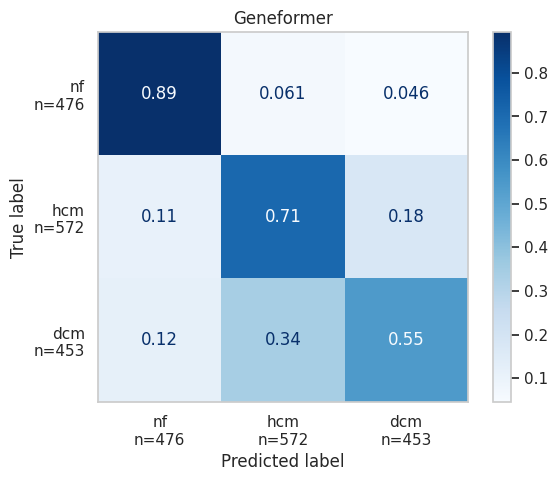

✅ Confusion matrix saved
🔍 Available prediction files: ['cardiomyopathy_classifier_test_pred_dict.pkl']
✅ Predictions plot saved


<Figure size 1500x1500 with 0 Axes>

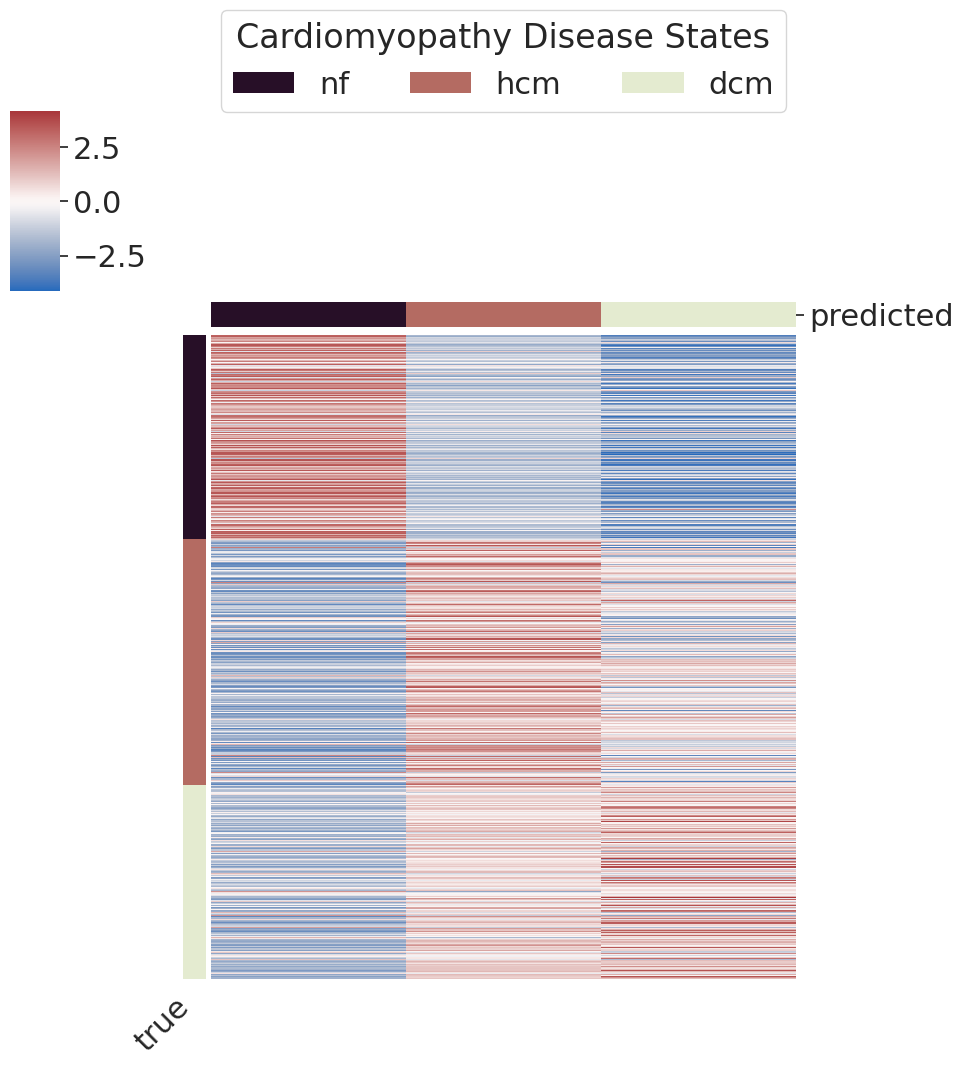

In [38]:

# =============================================================================
# CREATE PLOTS
# =============================================================================

if all_metrics_test:
    print(f"\n📊 Creating plots...")

    import matplotlib.pyplot as plt
    import seaborn as sns

    # Get unique disease states
    unique_diseases = list(disease_counts.keys())

    # Basic Geneformer plots
    try:
        eval_cc.plot_conf_mat(
            conf_mat_dict={"Geneformer": all_metrics_test["conf_matrix"]},
            output_directory=output_dir,
            output_prefix=CONFIG["output_prefix"],
            custom_class_order=unique_diseases,
        )
        print("✅ Confusion matrix saved")
    except Exception as e:
        print(f"❌ Confusion matrix failed: {e}")

    try:
        # Check what prediction files exist
        pred_files = [f for f in os.listdir(output_dir) if "pred_dict.pkl" in f]
        print(f"🔍 Available prediction files: {pred_files}")

        # Use the correct prediction file (with _test suffix from evaluation)
        predictions_file = f"{output_dir}/{CONFIG['output_prefix']}_test_pred_dict.pkl"

        if not os.path.exists(predictions_file):
            print(f"❌ Prediction file not found: {predictions_file}")
            print("🔍 Checking for alternative prediction files...")
            if pred_files:
                predictions_file = f"{output_dir}/{pred_files[0]}"
                print(f"💡 Using alternative file: {predictions_file}")
            else:
                print("❌ No prediction files found - skipping predictions plot")
                raise FileNotFoundError("No prediction files found")

        eval_cc.plot_predictions(
            predictions_file=predictions_file,
            id_class_dict_file=f"{output_dir}/{CONFIG['output_prefix']}_id_class_dict.pkl",
            title="Cardiomyopathy Disease States",
            output_directory=output_dir,
            output_prefix=CONFIG["output_prefix"],
            custom_class_order=unique_diseases,
        )
        print("✅ Predictions plot saved")
    except Exception as e:
        print(f"❌ Predictions plot failed: {e}")

In [39]:

# =============================================================================
# SAVE SUMMARY
# =============================================================================

print(f"\n📝 Saving summary...")

summary_file = f"{output_dir}/{CONFIG['output_prefix']}_simple_summary.txt"
with open(summary_file, 'w') as f:
    f.write("Cardiomyopathy Geneformer Training Summary\n")
    f.write("=" * 50 + "\n\n")

    f.write(f"Date: {current_date.strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Output directory: {output_dir}\n\n")

    f.write("Dataset Information:\n")
    f.write(f"  Total cells: {len(dataset)}\n")
    f.write("  Disease distribution:\n")
    for disease, count in disease_counts.items():
        f.write(f"    {disease}: {count}\n")
    f.write("\n")

    f.write("Training Configuration:\n")
    for key, value in training_args.items():
        f.write(f"  {key}: {value}\n")
    f.write("\n")

    if all_metrics_test:
        f.write("Test Results:\n")
        for key, value in all_metrics_test.items():
            if isinstance(value, (int, float)):
                f.write(f"  {key}: {value:.4f}\n")
            else:
                f.write(f"  {key}: {value}\n")

print(f"✅ Summary saved to: {summary_file}")


📝 Saving summary...
✅ Summary saved to: /content/cardiomyopathy_output/250821194621/cardiomyopathy_classifier_simple_summary.txt


In [40]:
# =============================================================================
# FINAL SUMMARY
# =============================================================================

print(f"\n🎉 Training pipeline completed!")
print("=" * 60)

print(f"📁 Output directory: {output_dir}")
print(f"📊 Dataset: {len(dataset)} cells, {len(disease_counts)} disease states")
print(f"🔧 Model: {CONFIG['model_version']} fine-tuned for cardiomyopathy")

if all_metrics_test:
    print(f"📈 Test accuracy: {all_metrics_test.get('acc', 'N/A')}")
    print(f"📈 Test F1: {all_metrics_test.get('macro_f1', 'N/A')}")

print(f"\n📋 Generated files:")
print("  📊 Plots:")
print("    - Confusion matrix")
print("    - Predictions plot")
print("  📁 Data:")
print("    - Prepared dataset")
print("    - ID class dictionary")
print("    - Prediction files")
print("  📝 Summary:")
print("    - Training summary")
print("  🧠 Model:")
print("    - Trained model files")

print(f"\n✅ All done! Check the output directory for results.")


🎉 Training pipeline completed!
📁 Output directory: /content/cardiomyopathy_output/250821194621
📊 Dataset: 9998 cells, 3 disease states
🔧 Model: V1 fine-tuned for cardiomyopathy
📈 Test accuracy: 0.7181878747501665
📈 Test F1: 0.7114950311862209

📋 Generated files:
  📊 Plots:
    - Confusion matrix
    - Predictions plot
  📁 Data:
    - Prepared dataset
    - ID class dictionary
    - Prediction files
  📝 Summary:
    - Training summary
  🧠 Model:
    - Trained model files

✅ All done! Check the output directory for results.


In [43]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [45]:
!ls -1 "/content/drive/My Drive/geneformer_test4_cardiomyopathy"

In [42]:
!ls -1 /content/cardiomyopathy_output/250821194621

250821_geneformer_cellClassifier_cardiomyopathy_classifier
cardiomyopathy_classifier_conf_mat.pdf
cardiomyopathy_classifier_id_class_dict.pkl
cardiomyopathy_classifier_labeled_test.dataset
cardiomyopathy_classifier_labeled_train.dataset
cardiomyopathy_classifier_pred.pdf
cardiomyopathy_classifier_simple_summary.txt
cardiomyopathy_classifier_test_pred_dict.pkl
cardiomyopathy_classifier_test_test_metrics_dict.pkl
cardiomyopathy_classifier_with_splits.dataset


In [1]:
# To continue with the insilico perturbation

In [48]:
!cp -r /content/cardiomyopathy_output/250821194621 "/content/drive/My Drive/geneformer_test4_cardiomyopathy"

In [49]:
!ls -1 "/content/drive/My Drive/geneformer_test4_cardiomyopathy"

250821194621


In [2]:
!ls -1 "/content/drive/My Drive/geneformer_test4_cardiomyopathy/250821194621"

ls: cannot access '/content/drive/My Drive/geneformer_test4_cardiomyopathy/250821194621': No such file or directory
